# 01 · StarGAN + PGD baseline

**Goal (Review-1):** show that a small invisible perturbation on a face photo makes
StarGAN's face edits come out broken.

Pipeline: CelebA test face → StarGAN edits it normally → we add a PGD perturbation
(ε = 8/255) → StarGAN's edits on the protected photo are distorted.

**Before you start:** Runtime → Change runtime type → **T4 GPU**.
You need the `KAGGLE_API_TOKEN` secret in Colab (🔑 icon on the left) from the dataset step.

Run the cells top to bottom.

## 1 · Setup

In [2]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - switch runtime to T4 GPU")

GPU: Tesla T4


In [3]:
# Clone our repo (for attack/pgd.py and eval/metrics.py) and the official StarGAN code
!git clone -q https://github.com/Liya-17/immunize.git
%cd immunize
!git clone -q https://github.com/yunjey/stargan.git stargan_official
!pip install -q kagglehub scikit-image

/content/immunize


## 2 · Test faces (CelebA test split) and their attribute labels

In [4]:
import os, kagglehub
from google.colab import userdata
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
CELEBA = kagglehub.dataset_download("jessicali9530/celeba-dataset")
IMG_DIR = f"{CELEBA}/img_align_celeba/img_align_celeba"
PART_CSV = f"{CELEBA}/list_eval_partition.csv"
ATTR_CSV = f"{CELEBA}/list_attr_celeba.csv"
print(os.listdir(CELEBA))

Using Colab cache for faster access to the 'celeba-dataset' dataset.
['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [5]:
import pandas as pd

N_IMAGES = 20   # start small; increase to 100-200 for the final results table

parts = pd.read_csv(PART_CSV)
attrs = pd.read_csv(ATTR_CSV).set_index("image_id")
test_ids = parts[parts["partition"] == 2]["image_id"].head(N_IMAGES).tolist()

# StarGAN was trained on these 5 attributes (in this order)
SELECTED = ["Black_Hair", "Blond_Hair", "Brown_Hair", "Male", "Young"]
labels = ((attrs.loc[test_ids, SELECTED].values + 1) // 2).astype("float32")  # -1/1 -> 0/1
print(len(test_ids), "test images, e.g.", test_ids[0], dict(zip(SELECTED, labels[0])))

20 test images, e.g. 182638.jpg {'Black_Hair': np.float32(0.0), 'Blond_Hair': np.float32(0.0), 'Brown_Hair': np.float32(0.0), 'Male': np.float32(0.0), 'Young': np.float32(0.0)}


## 3 · Load pretrained StarGAN (CelebA, 256×256)

Weights come from the official StarGAN repo. They are **not** committed to GitHub.

In [6]:
!mkdir -p weights
!wget -q -O weights/stargan256.zip "https://www.dropbox.com/s/zdq6roqf63m0v5f/celeba-256x256-5attrs.zip?dl=1"
!unzip -q -o weights/stargan256.zip -d weights/stargan256
!find weights/stargan256 -name "*.ckpt"

weights/stargan256/200000-D.ckpt
weights/stargan256/200000-G.ckpt


In [7]:
import glob, sys, torch
sys.path.insert(0, "stargan_official")
from model import Generator

device = "cuda" if torch.cuda.is_available() else "cpu"
G = Generator(conv_dim=64, c_dim=5, repeat_num=6).to(device)

ckpt = sorted(glob.glob("weights/stargan256/**/*-G.ckpt", recursive=True))
assert ckpt, "Generator checkpoint not found - check the download cell above"
G.load_state_dict(torch.load(ckpt[-1], map_location=device))
G.eval()
for p in G.parameters():
    p.requires_grad_(False)
print("Loaded", ckpt[-1])

Loaded weights/stargan256/200000-G.ckpt


## 4 · Wrap StarGAN so our attack code can use it

`attack/pgd.py` expects `model(x) -> image`, with images in [0, 1].
StarGAN works in [-1, 1] and also needs a target-attribute vector `c`.

For each photo we build the **5 standard StarGAN edits** (black / blond / brown hair,
flip gender, flip age) exactly like StarGAN's own test code. The wrapper runs all 5 and
stacks the outputs, so PGD learns **one** perturbation that breaks **every** edit.

In [8]:
import torch.nn as nn
from PIL import Image
from torchvision import transforms as T

EDIT_NAMES = ["Black hair", "Blond hair", "Brown hair", "Flip gender", "Flip age"]

def target_labels(c_org):
    """Same logic as StarGAN's create_labels() for CelebA."""
    targets = []
    for i in range(5):
        c = c_org.clone()
        if i < 3:                      # hair colour: set one, clear the others
            c[:3] = 0
            c[i] = 1
        else:                          # gender / age: flip
            c[i] = 1 - c[i]
        targets.append(c)
    return torch.stack(targets)        # 5 x 5

class StarGANEdits(nn.Module):
    """x in [0,1] (1x3xHxW) -> the 5 edited images in [0,1], shape 5x3xHxW."""
    def __init__(self, G, c_targets):
        super().__init__()
        self.G, self.c = G, c_targets
    def forward(self, x):
        x = x.expand(len(self.c), -1, -1, -1) * 2 - 1
        return (self.G(x, self.c) + 1) / 2

preprocess = T.Compose([T.CenterCrop(178), T.Resize(256), T.ToTensor()])   # StarGAN's own CelebA transform

def load_face(image_id):
    return preprocess(Image.open(f"{IMG_DIR}/{image_id}").convert("RGB")).unsqueeze(0).to(device)

## 5 · Protect one photo and look at the result

Invisibility  PSNR = 31.4 dB   SSIM = 0.743
Disruption    output L2 = 291.0


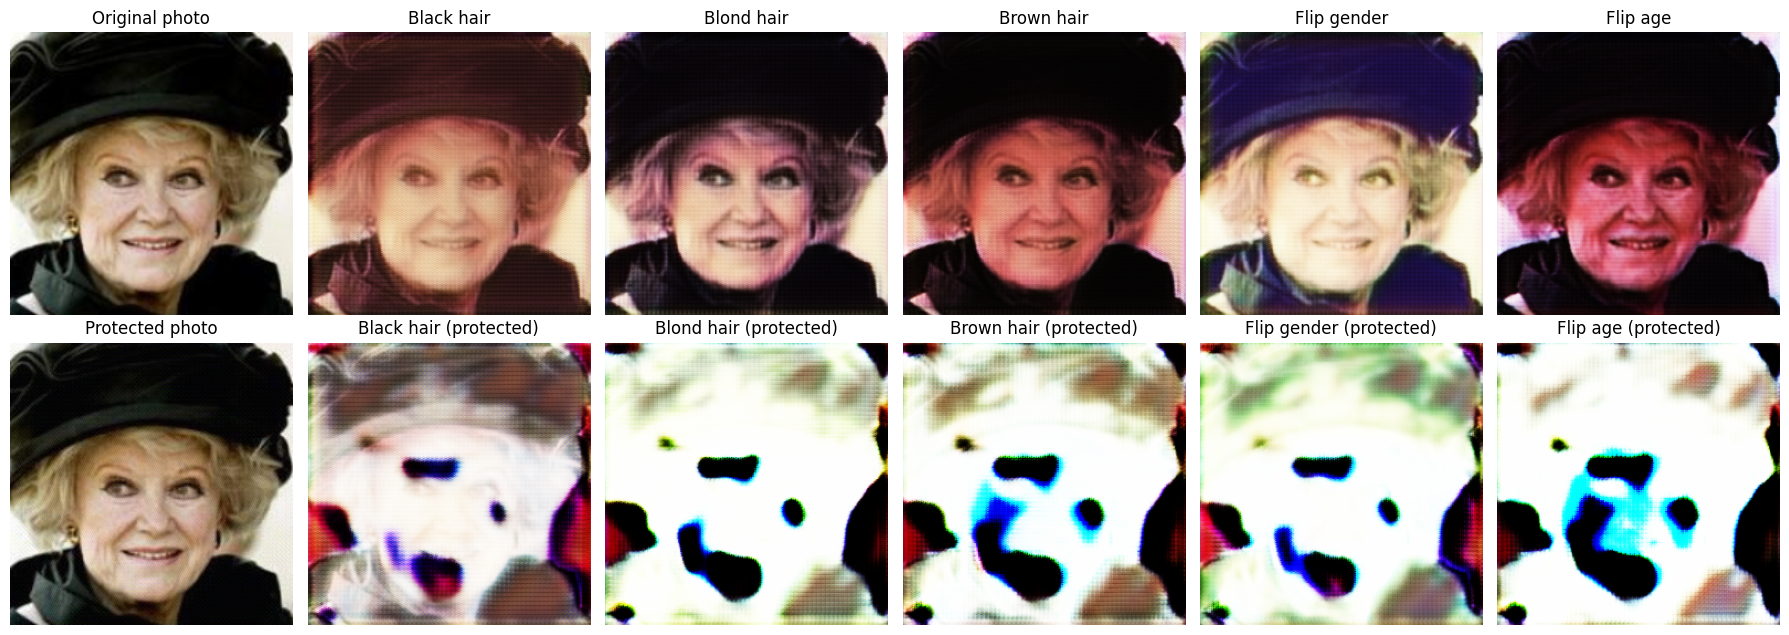

In [9]:
import matplotlib.pyplot as plt
from attack.pgd import pgd_disrupt
from eval.metrics import psnr, ssim, output_l2

EPS, STEPS = 8/255, 40

def show(t):
    return t.squeeze(0).permute(1, 2, 0).detach().cpu().clamp(0, 1).numpy()

idx = 0
x = load_face(test_ids[idx])
model = StarGANEdits(G, target_labels(torch.tensor(labels[idx])).to(device))

x_prot = pgd_disrupt(model, x, eps=EPS, steps=STEPS)
with torch.no_grad():
    out_clean, out_prot = model(x), model(x_prot)

print(f"Invisibility  PSNR = {psnr(x, x_prot):.1f} dB   SSIM = {ssim(x, x_prot):.3f}")
print(f"Disruption    output L2 = {output_l2(out_clean, out_prot):.1f}")

fig, ax = plt.subplots(2, 6, figsize=(18, 6.5))
ax[0, 0].imshow(show(x));      ax[0, 0].set_title("Original photo")
ax[1, 0].imshow(show(x_prot)); ax[1, 0].set_title("Protected photo")
for j in range(5):
    ax[0, j + 1].imshow(show(out_clean[j])); ax[0, j + 1].set_title(EDIT_NAMES[j])
    ax[1, j + 1].imshow(show(out_prot[j]));  ax[1, j + 1].set_title(EDIT_NAMES[j] + " (protected)")
for a in ax.flat:
    a.axis("off")
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/before_after.png", dpi=120)
plt.show()

**What you should see:** top row = normal StarGAN edits. Bottom row = the protected
photo looks the same as the original, but every edit is heavily distorted.

## 6 · Run on all test images and build the results table

In [10]:
import time
from tqdm.auto import tqdm

def evaluate(eps, steps=STEPS, n=N_IMAGES):
    rows = []
    for i in tqdm(range(n), desc=f"eps={round(eps*255)}/255"):
        x = load_face(test_ids[i])
        model = StarGANEdits(G, target_labels(torch.tensor(labels[i])).to(device))
        t0 = time.time()
        x_prot = pgd_disrupt(model, x, eps=eps, steps=steps)
        secs = time.time() - t0
        with torch.no_grad():
            oc, op = model(x), model(x_prot)
        rows.append({"image": test_ids[i], "eps": f"{round(eps*255)}/255",
                     "psnr": psnr(x, x_prot), "ssim": ssim(x, x_prot),
                     "output_l2": output_l2(oc, op),
                     "output_mse": torch.mean((oc - op) ** 2).item(),
                     "seconds": secs})
    return pd.DataFrame(rows)

results = pd.concat([evaluate(e) for e in (4/255, 8/255, 16/255)])
summary = results.groupby("eps", sort=False)[["psnr", "ssim", "output_l2", "output_mse", "seconds"]].mean().round(4)
results.to_csv("results/baseline_results.csv", index=False)
summary

eps=4/255:   0%|          | 0/20 [00:00<?, ?it/s]

eps=8/255:   0%|          | 0/20 [00:00<?, ?it/s]

eps=16/255:   0%|          | 0/20 [00:00<?, ?it/s]

,psnr,ssim,output_l2,output_mse,seconds
eps,,,,,
4/255,37.0870,0.9107,216.5049,0.2784,9.7242
8/255,31.3204,0.7556,289.3654,0.4460,10.6080
16/255,26.0878,0.5377,327.9366,0.5550,10.6612


Copy the `summary` table into the **Results** table in `README.md`.
Expected trade-off: larger ε → stronger disruption but lower PSNR (more visible).

## 7 · Save results to Google Drive (share this folder with the team)

In [11]:
from google.colab import drive
import shutil
drive.mount("/content/drive")
shutil.copytree("results", "/content/drive/MyDrive/immunize/results", dirs_exist_ok=True)
print("Saved to MyDrive/immunize/results")

Mounted at /content/drive
Saved to MyDrive/immunize/results


Using 20 faces, 40 PGD steps, device cuda


pgd eps=4/255:   0%|          | 0/20 [00:00<?, ?it/s]

uniform_noise eps=4/255:   0%|          | 0/20 [00:00<?, ?it/s]

sign_noise eps=4/255:   0%|          | 0/20 [00:00<?, ?it/s]

pgd eps=8/255:   0%|          | 0/20 [00:00<?, ?it/s]

uniform_noise eps=8/255:   0%|          | 0/20 [00:00<?, ?it/s]

sign_noise eps=8/255:   0%|          | 0/20 [00:00<?, ?it/s]

psnr    ssim  output_l2  output_mse success_rate
eps   method                                                            
4/255 pgd            37.0933  0.9109   213.8261      0.2701       100.0%
      uniform_noise  40.9593  0.9608    11.4600      0.0009         0.0%
      sign_noise     36.2119  0.8946    20.1354      0.0029         0.0%
8/255 pgd            31.3550  0.7573   289.8635      0.4466       100.0%
      uniform_noise  35.0082  0.8695    23.0941      0.0037         0.0%
      sign_noise     30.2856  0.7155    39.8117      0.0105         0.0%

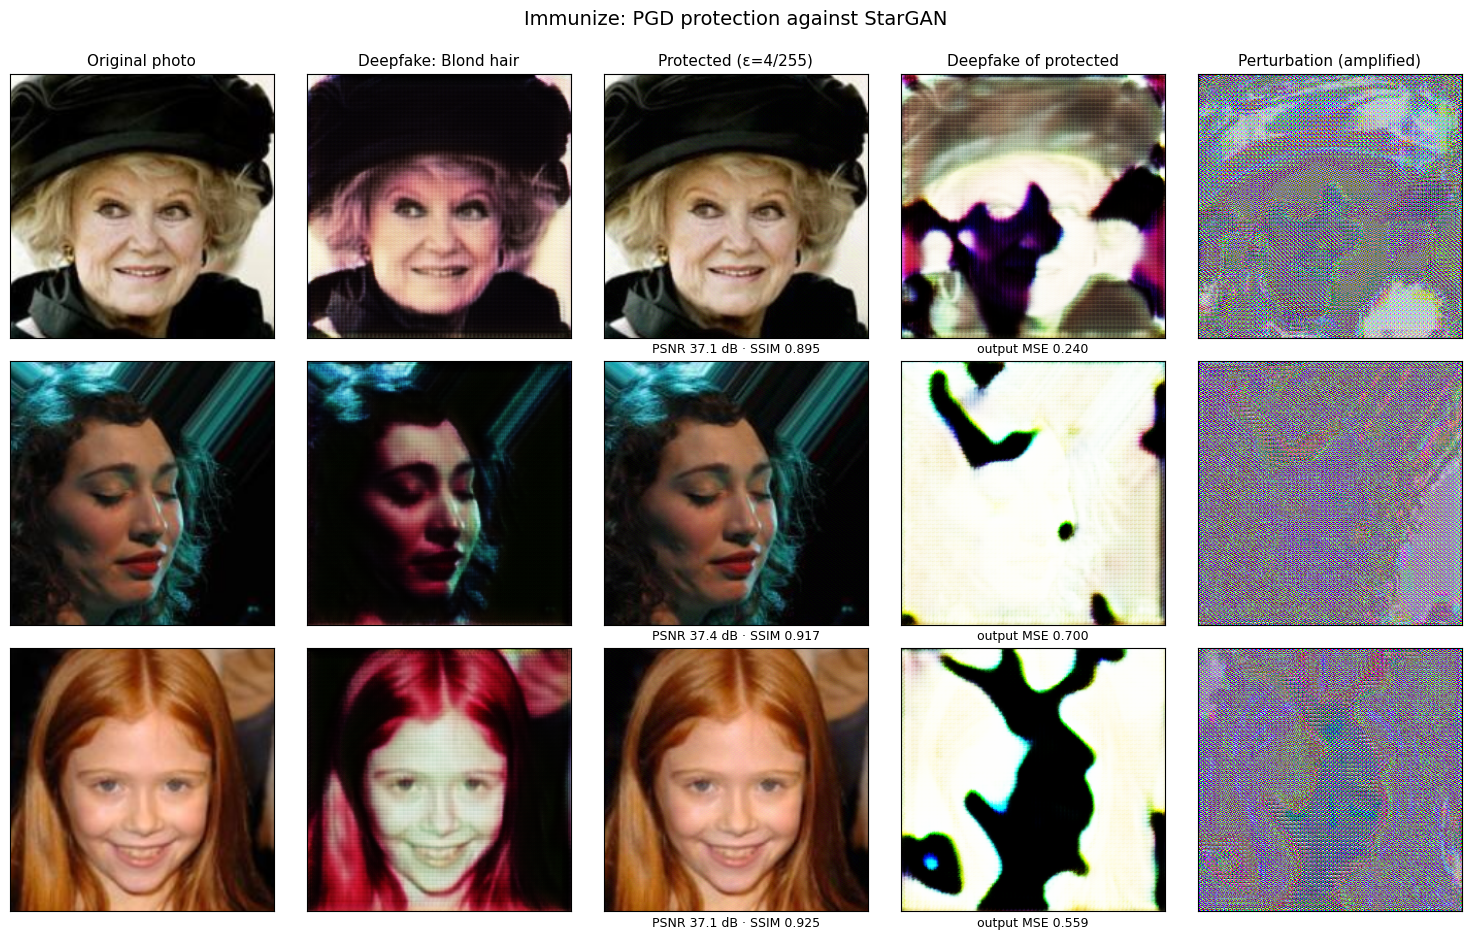

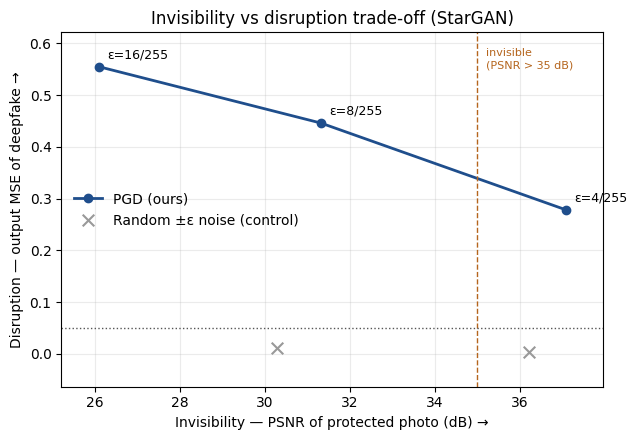

| eps   | method        |   PSNR |   SSIM |   Output_MSE | Success   |   Seconds |
|:------|:--------------|-------:|-------:|-------------:|:----------|----------:|
| 4/255 | pgd           |  37.09 |  0.911 |        0.27  | 100%      |      10.7 |
| 4/255 | uniform_noise |  40.96 |  0.961 |        0.001 | 0%        |       0   |
| 4/255 | sign_noise    |  36.21 |  0.895 |        0.003 | 0%        |       0   |
| 8/255 | pgd           |  31.35 |  0.757 |        0.447 | 100%      |      10.6 |
| 8/255 | uniform_noise |  35.01 |  0.869 |        0.004 | 0%        |       0   |
| 8/255 | sign_noise    |  30.29 |  0.716 |        0.011 | 0%        |       0   |


In [14]:
# =====================================================================
#  Immunize — Phase 1 extras for 01_stargan_pgd_baseline.ipynb
#  Paste each CELL block below into its own NEW cell at the END of notebook 01
#  (after cell 10, the eps = 4/8/16 results table). Nothing to edit —
#  it uses the names already defined in your notebook.
#
#  Adds:
#    CELL 2  Random-noise control   -> proves disruption comes from PGD, not noise
#    CELL 3  Before/after figure    -> clean->fake  vs  protected->broken fake
#    CELL 4  Trade-off plot         -> invisibility (PSNR) vs disruption (MSE)
#    CELL 5  Final Review-1 table   -> one CSV + markdown table for README/slides
# =====================================================================


# %% ------------------------------------------------------------------
# CELL 1 — SETUP  (uses the names already defined in notebook 01:
#          G, device, test_ids, labels, load_face, target_labels,
#          StarGANEdits, EDIT_NAMES, N_IMAGES, STEPS)
# ---------------------------------------------------------------------
import os, time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

from attack.pgd import pgd_disrupt
from eval.metrics import psnr, ssim, output_l2

MSE_SUCCESS = 0.05      # disruption "success" threshold (Ruiz et al. 2020) — confirm in the paper
os.makedirs("results", exist_ok=True)
os.makedirs("docs/figures", exist_ok=True)

def face_and_model(i):
    """Same as your evaluate(): face i + a StarGAN wrapper with that face's 5 target edits."""
    x = load_face(test_ids[i])
    model = StarGANEdits(G, target_labels(torch.tensor(labels[i])).to(device))
    return x, model

print(f"Using {N_IMAGES} faces, {STEPS} PGD steps, device {device}")


# %% ------------------------------------------------------------------
# CELL 2 — RANDOM-NOISE CONTROL
# ---------------------------------------------------------------------
# Same L-infinity budget (eps) for every method, so the comparison is fair:
#   pgd           : optimised perturbation (your method)
#   uniform_noise : random values in [-eps, +eps]
#   sign_noise    : random +eps / -eps on every pixel (strongest random noise
#                   with the same budget — even this should NOT break StarGAN)
# Expected: PGD output_mse >> noise output_mse, success rate ~100% vs ~0%.
# Runtime on a T4: about 8 minutes (PGD is re-run; noise is instant).

def make_perturbed(model, x, method, eps):
    if method == "pgd":
        return pgd_disrupt(model, x, eps=eps, steps=STEPS)
    if method == "uniform_noise":
        d = torch.empty_like(x).uniform_(-eps, eps)
    elif method == "sign_noise":
        d = eps * (torch.randint(0, 2, x.shape, device=x.device).float() * 2 - 1)
    else:
        raise ValueError(method)
    return (x + d).clamp(0, 1)


def run_method(method, eps, seed=0):
    torch.manual_seed(seed)
    rows = []
    for i in tqdm(range(N_IMAGES), desc=f"{method} eps={round(eps * 255)}/255", leave=False):
        x, model = face_and_model(i)
        t0 = time.time()
        x_adv = make_perturbed(model, x, method, eps)
        secs = time.time() - t0
        with torch.no_grad():
            oc, op = model(x), model(x_adv)            # 5 edits each
        mse = torch.mean((oc - op) ** 2).item()         # same formula as your evaluate()
        rows.append({
            "method": method, "eps": f"{round(eps * 255)}/255", "image": test_ids[i],
            "psnr": psnr(x, x_adv), "ssim": ssim(x, x_adv),
            "output_l2": output_l2(oc, op), "output_mse": mse,
            "success": mse >= MSE_SUCCESS, "seconds": secs,
        })
    return pd.DataFrame(rows)


control = pd.concat(
    [run_method(m, e) for e in (4 / 255, 8 / 255)
                      for m in ("pgd", "uniform_noise", "sign_noise")],
    ignore_index=True,
)
control.to_csv("results/noise_control.csv", index=False)

control_summary = (
    control.groupby(["eps", "method"], sort=False)
    .agg(psnr=("psnr", "mean"), ssim=("ssim", "mean"),
         output_l2=("output_l2", "mean"), output_mse=("output_mse", "mean"),
         success_rate=("success", "mean"))
    .round(4)
)
control_summary["success_rate"] = (control_summary["success_rate"] * 100).round(1).astype(str) + "%"
display(control_summary)


# %% ------------------------------------------------------------------
# CELL 3 — BEFORE / AFTER FIGURE  (eps = 4/255, the chosen setting)
# ---------------------------------------------------------------------
# One row per face. Columns: original | edit of original | protected (looks
# the same) | edit of protected (broken) | perturbation (amplified to be visible)
FIG_EPS = 4 / 255
N_SHOW = 3            # number of faces (rows)
EDIT = 1              # which StarGAN edit to show: 0..4 -> EDIT_NAMES
torch.manual_seed(0)

def to_img(t):
    t = t if t.dim() == 3 else t[0]
    return t.detach().clamp(0, 1).permute(1, 2, 0).cpu().numpy()

titles = ["Original photo", f"Deepfake: {EDIT_NAMES[EDIT]}",
          f"Protected (ε={round(FIG_EPS * 255)}/255)", f"Deepfake of protected",
          "Perturbation (amplified)"]
fig, axes = plt.subplots(N_SHOW, 5, figsize=(15, 3.1 * N_SHOW))
axes = np.atleast_2d(axes)

for r in range(N_SHOW):
    x, model = face_and_model(r)
    x_adv = pgd_disrupt(model, x, eps=FIG_EPS, steps=STEPS)
    with torch.no_grad():
        fake_clean, fake_adv = model(x)[EDIT], model(x_adv)[EDIT]
    delta_vis = ((x_adv - x) / FIG_EPS + 1) / 2      # map [-eps, eps] -> [0, 1]
    for c, p in enumerate([x, fake_clean, x_adv, fake_adv, delta_vis]):
        axes[r, c].imshow(to_img(p))
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title(titles[c], fontsize=11)
    axes[r, 2].set_xlabel(f"PSNR {psnr(x, x_adv):.1f} dB · SSIM {ssim(x, x_adv):.3f}", fontsize=9)
    axes[r, 3].set_xlabel(f"output MSE {torch.mean((fake_adv - fake_clean) ** 2).item():.3f}", fontsize=9)

fig.suptitle("Immunize: PGD protection against StarGAN", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig("docs/figures/before_after_eps4.png", dpi=200, bbox_inches="tight")
plt.show()


# %% ------------------------------------------------------------------
# CELL 4 — TRADE-OFF PLOT  (uses results/baseline_results.csv from the baseline cell)
# ---------------------------------------------------------------------
base = pd.read_csv("results/baseline_results.csv")
def _eps_to_255(v):                     # accepts "4/255" or 0.0157
    s = str(v)
    return float(s.split("/")[0]) if "/" in s else round(float(s) * 255)
base["eps_num"] = base["eps"].map(_eps_to_255)
curve = base.groupby("eps_num").agg(psnr=("psnr", "mean"), mse=("output_mse", "mean")).reset_index()

noise = control[control["method"] == "sign_noise"].groupby("eps").agg(
    psnr=("psnr", "mean"), mse=("output_mse", "mean")).reset_index()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(curve["psnr"], curve["mse"], "o-", color="#1f4e8c", lw=2, label="PGD (ours)")
for _, r in curve.iterrows():
    ax.annotate(f"ε={int(r.eps_num)}/255", (r.psnr, r.mse), textcoords="offset points",
                xytext=(6, 6), fontsize=9)
ax.scatter(noise["psnr"], noise["mse"], marker="x", s=70, color="#999999",
           label="Random ±ε noise (control)")
ax.margins(x=0.08, y=0.12)
ax.axvline(35, ls="--", color="#b5651d", lw=1)
ax.text(35.2, ax.get_ylim()[1] * 0.95, "invisible\n(PSNR > 35 dB)", fontsize=8,
        color="#b5651d", va="top")
ax.axhline(MSE_SUCCESS, ls=":", color="#555555", lw=1)
ax.set_xlabel("Invisibility — PSNR of protected photo (dB) →")
ax.set_ylabel("Disruption — output MSE of deepfake →")
ax.set_title("Invisibility vs disruption trade-off (StarGAN)")
ax.legend(frameon=False, loc="center left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("docs/figures/tradeoff_psnr_vs_mse.png", dpi=200, bbox_inches="tight")
plt.show()


# %% ------------------------------------------------------------------
# CELL 5 — FINAL REVIEW-1 TABLE  (copy the printed markdown into README / slides)
# ---------------------------------------------------------------------
final = (
    control.groupby(["eps", "method"], sort=False)
    .agg(PSNR=("psnr", "mean"), SSIM=("ssim", "mean"),
         Output_MSE=("output_mse", "mean"), Success=("success", "mean"),
         Seconds=("seconds", "mean"))
    .reset_index()
)
final["Success"] = (final["Success"] * 100).round(0).astype(int).astype(str) + "%"
final = final.round({"PSNR": 2, "SSIM": 3, "Output_MSE": 3, "Seconds": 1})
final.to_csv("results/review1_table.csv", index=False)
try:
    print(final.to_markdown(index=False))
except ImportError:                      # tabulate not installed
    print(final.to_string(index=False))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')